### Point Tracking DeepTrack Demo

#### ProcessPointData is the script that trains the DeepTrack LodeSTAR model with the first frame of the video. The model weights can be saved. 

#### You only need to train the model once, then simply load the model weights and use it to track the points in all other videos with process_video.py CLI.

#### The notebook contains a demo of how to use the model to track points in a video.

In [1]:
import os, sys
import cv2
module_path = os.path.abspath(os.path.join(os.path.expanduser('~/NSF_Project/Distraction1/')))
if not module_path in sys.path:
    print("appending path")
    sys.path.append(module_path)

print(sys.path)
import DeepTrackUtils 
from matplotlib import pyplot as plt

 

%load_ext autoreload
%autoreload 2
%matplotlib widget


appending path
['/path/to/cloned/directory/CMU-MultimodalSDK', '/home/peter/NSF_Project/Distraction1/Benefit_of_Distraction-master1/get_Dyno/training', '/home/peter/.conda/envs/syndyn/lib/python310.zip', '/home/peter/.conda/envs/syndyn/lib/python3.10', '/home/peter/.conda/envs/syndyn/lib/python3.10/lib-dynload', '', '/home/peter/.local/lib/python3.10/site-packages', '/home/peter/.conda/envs/syndyn/lib/python3.10/site-packages', '/home/peter/NSF_Project/Distraction1']


In [2]:
import numpy as np

def to_blob_8u(img):
    # Convert to grayscale if needed
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Already correct type
    if img.dtype == np.uint8:
        return img.copy()

    # Normalize safely to [0,255] and convert
    img8 = cv2.normalize(
        img, None, 0, 255,
        norm_type=cv2.NORM_MINMAX,
        dtype=cv2.CV_8U
    )
    return img8

### Annotate the image with blob detection

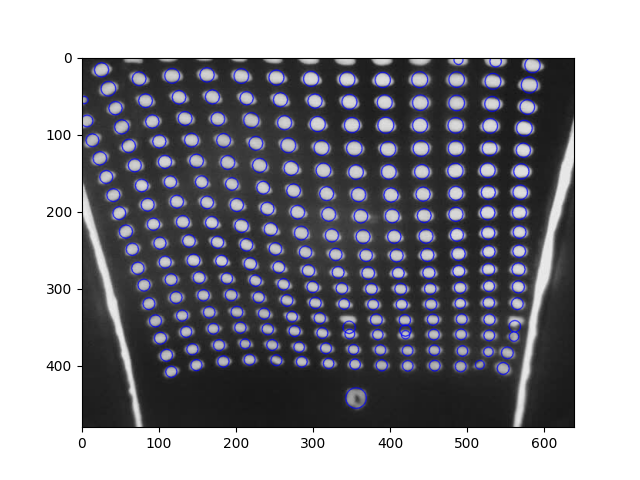

In [3]:
video_folder = "/home/peter/DynoNAS/Peter/Research_data/"
video_file_name  = '7_2024y_03m_19d_08h_10m_35s_594ms_614us_tracking_0/2024y_03m_19d_08h_10m_35s_594ms_614us_tracking_0_ground_truth.avi'
video_path  = os.path.join(video_folder, video_file_name)

cap = cv2.VideoCapture(video_path)
i = 0
while cap.isOpened():
    ret, image = cap.read()
    if not ret:
        break
    
    if i == 0 :
        pass
        # plt.figure()
        # plt.imshow(image)
        # plt.show()
    
    if i > 0:
        break
    
    i += 1

cap.release()

image = to_blob_8u(image)
params = cv2.SimpleBlobDetector_Params()
# --- Thresholding (MOST IMPORTANT) ---
params.minThreshold = 50
params.maxThreshold = 220
params.thresholdStep = 10

# --- Color (optional, but strong) ---
params.filterByColor = True
params.blobColor = 255

# --- Area (reject small / large blobs) ---
params.filterByArea = True
params.minArea = 50.0
params.maxArea = 1000.0
params.filterByCircularity = False
params.minCircularity = 0.5
# --- Convexity (reject jagged / fuzzy edges) ---
params.filterByConvexity = True
params.minConvexity = 0.4

# --- Inertia (reject elongated shapes) ---
params.filterByInertia = True
params.minInertiaRatio = 0.2


detector = cv2.SimpleBlobDetector_create(params)
keypoints = detector.detect(image)


# Draw blobs as red circles
output = cv2.drawKeypoints(image, keypoints, np.array([]), (0, 0, 255),
                           cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
 
# Show the output
plt.figure()
plt.imshow(output)
plt.show()



### Create bounding box and crop into training data

In [4]:
H, W = image.shape
patches = []
patch_boxes = []

for i, kp in enumerate(keypoints):
    x, y = kp.pt
    r = kp.size / 2.0 + 6

    # Compute bounds
    x1 = int(np.floor(x - r))
    y1 = int(np.floor(y - r))
    x2 = int(np.ceil (x + r))
    y2 = int(np.ceil (y + r))

    # Clip to image bounds
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(W, x2)
    y2 = min(H, y2)

    # Crop
    patch = image[y1:y2, x1:x2]

    patches.append(patch)
    patch_boxes.append([x1, y1, x2, y2])


os.makedirs(os.path.expanduser("~/NSF_Project/Distraction1/Benefit_of_Distraction-master1/get_Dyno/training/dot_patches"), exist_ok=True)

for i, patch in enumerate(patches):
    cv2.imwrite(f"dot_patches/dot_{i:03d}.png", patch)

### Train the deeptrack model from data in data folder `/get_Dyno/training/dot_patches`

In [6]:
import torch
import deeptrack as dt
import deeptrack.deeplay as dl 
import glob

image_patches_dir = "~/NSF_Project/Distraction1/Benefit_of_Distraction-master1/get_Dyno/training/"
image_files = sorted(glob.glob(os.path.join(os.path.expanduser(image_patches_dir), "dot_patches" + "/*.png")))

dataset = dt.sources.ImageFolder(root=os.path.join(os.path.expanduser(image_patches_dir), "dot_patches"))

test_image = cv2.imread(image_files[0])

print(f"Dataset contains {len(dataset)} images")
# for item in dataset:
#     print(item["path"])
print("Train classes:", dataset.classes)

training_pipeline = (
    dt.Value(test_image)          # load image from disk
    >> dt.Resize((32, 32))                   # enforce fixed size
    >> dt.Multiply(lambda: np.random.uniform(0.9, 1.1))
    >> dt.Add(lambda: np.random.uniform(-0.1, 0.1))
    >> dt.NormalizeMinMax(0.0, 1.0)           # IMPORTANT for LodeSTAR
    >> dt.MoveAxis(-1, 0)                     # HWC → CHW
    >> dt.pytorch.ToTensor(dtype=torch.float32)
)

training_dataset = dt.pytorch.Dataset(training_pipeline, length=400, 
                                      replace=True)

tracker = DeepTrackUtils.DeepTrackTracker(
    n_transforms=4,
    lr=1e-4,
    capacity=500,
    max_distance=10,
)


tracker.train(
    training_dataset,
    batch_size=8,
    max_epochs=5,
)

Dataset contains 231 images
Train classes: ['dot_127.png', 'dot_151.png', 'dot_018.png', 'dot_009.png', 'dot_059.png', 'dot_057.png', 'dot_149.png', 'dot_175.png', 'dot_133.png', 'dot_0', 'dot_017.png', 'dot_055.png', 'dot_000.png', 'dot_157.png', 'dot_159.png', 'dot_200.png', 'dot_123.png', 'dot_015.png', 'dot_205.png', 'dot_044.png', 'dot_079.png', 'dot_076.png', 'dot_089.png', 'dot_032.png', 'dot_112.png', 'dot_193.png', 'dot_129.png', 'dot_189.png', 'dot_119.png', 'dot_033.png', 'dot_156.png', 'dot_008.png', 'dot_048.png', 'dot_084.png', 'dot_075.png', 'dot_092.png', 'dot_132.png', 'dot_196.png', 'dot_214.png', 'dot_036.png', 'dot_190.png', 'dot_019.png', 'dot_172.png', 'dot_131.png', 'dot_220.png', 'dot_042.png', 'dot_128.png', 'dot_100.png', 'dot_108.png', 'dot_221.png', 'dot_212.png', 'dot_104.png', 'dot_197.png', 'dot_130.png', 'dot_047.png', 'dot_106.png', 'dot_097.png', 'dot_039.png', 'dot_199.png', 'dot_095.png', 'dot_099.png', 'dot_070.png', 'dot_167.png', 'dot_215.png', 'd

/home/peter/.conda/envs/syndyn/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ ConvolutionalNeuralNetwork │  251 K │ train │     0 │
│ 1 │ between_loss  │ L1Loss                     │      0 │ train │     0 │
│ 2 │ within_loss   │ L1Loss                     │      0 │ train │     0 │
│ 3 │ train_metrics │ MetricCollection           │      0 │ train │     0 │
│ 4 │ val_metrics   │ MetricCollection           │      0 │ train │     0 │
│ 5 │ test_metrics  │ MetricCollection           │      0 │ train │     0 │
│ 6 │ optimizer     │ Adam                       │      0 │ train │     0 │
└───┴───────────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 251 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 251 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 39                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/peter/.conda/envs/syndyn/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


LodeSTAR(
  (model): ConvolutionalNeuralNetwork(
    (blocks): LayerList(
      (0): Conv2dBlock(
        (layer): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): ReLU()
      )
      (1): Conv2dBlock(
        (layer): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): ReLU()
      )
      (2): Conv2dBlock(
        (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (layer): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): ReLU()
      )
      (3-8): 6 x Conv2dBlock(
        (layer): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): ReLU()
      )
      (9): Conv2dBlock(
        (layer): Conv2d(64, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): Identity()
      )
    )
  )
  (between_loss): L1Loss()
  (within_loss): L1Loss()
  (optimizer): Adam[Adam](lr=0.0001, params=

### Save weights, load weights, and inference on new data.

In [ ]:
tracker.save_weights("weights.h5")
tracker = DeepTrackUtils.DeepTrackTracker(
    n_transforms=4,
    lr=1e-4,
    capacity=500,
    max_distance=10,
)
tracker.load_weights("weights.h5")